In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\hp\Downloads\archive (2)\suv_data.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
# drop the UserId as its not any important to the model 
df = df.drop("User ID", axis =1 )
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [4]:
# looking for the missing values 
print(df.isnull().sum())

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [5]:
df.shape

(400, 4)

In [6]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [7]:
print(df.duplicated().sum())

20


In [8]:
df[df.duplicated()]

,Gender,Age,EstimatedSalary,Purchased
74,Male,32,18000,0
94,Female,29,83000,0
186,Female,20,82000,0
192,Male,29,43000,0
231,Male,39,42000,0
236,Male,40,57000,0
256,Female,41,72000,0
257,Male,40,57000,0
312,Female,38,50000,0
322,Male,41,52000,0


In [9]:
df.duplicated().sum()

np.int64(20)

In [10]:
df = df.drop_duplicates()
print(df.shape)

(380, 4)


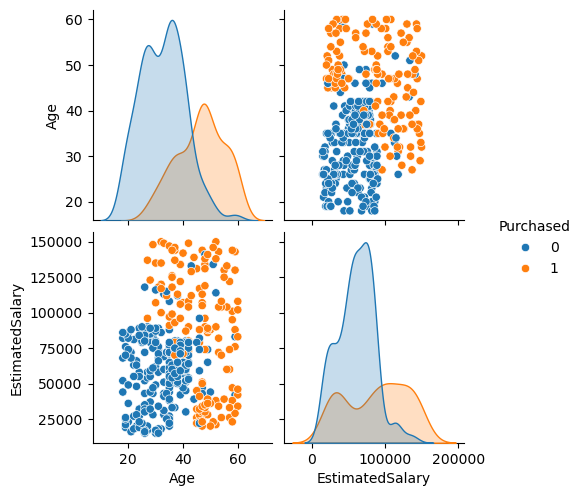

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt 
sns.pairplot(df , hue = 'Purchased')
plt.show()

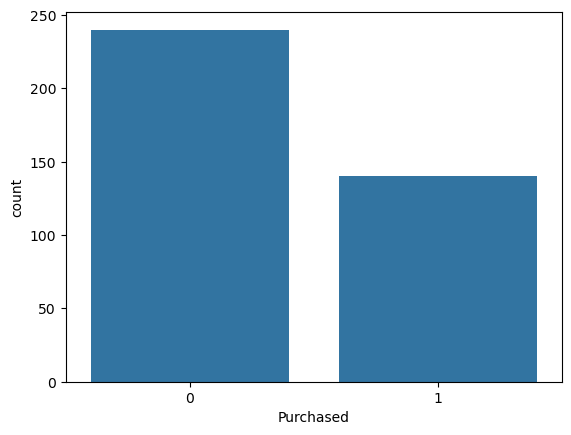

In [12]:
sns.countplot(x='Purchased' , data = df)
plt.show()

In [13]:
df['Gender']= df['Gender'].map({'Male':1,'Female':0})

In [14]:
from sklearn.model_selection import train_test_split
x = df[['Gender', 'Age', 'EstimatedSalary']]
y = df['Purchased']
x_train,x_test,y_train, y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [16]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Create an imputer to handle NaN values
# strategy can be 'mean', 'median', 'most_frequent', or 'constant'
imputer = SimpleImputer(strategy='mean')

# Apply the imputer to the training data
x_train_imputed = imputer.fit_transform(x_train)

models = {
    "Logistic": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "DecisionTree": DecisionTreeClassifier(),
    "NaiveBayes": GaussianNB()
}

for name, model in models.items():
    # Use the imputed data for training
    model.fit(x_train_imputed, y_train)
    print(f"{name} trained")

Logistic trained
KNN trained
SVM trained
DecisionTree trained
NaiveBayes trained


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer

# Create an imputer to replace NaN values with the mean of each column
imputer = SimpleImputer(strategy='mean')

# Fit and transform the imputer on X_test to replace NaN values
X_test_imputed = imputer.fit_transform(X_test)

# Now use the imputed data for predictions
for name, model in models.items():
    y_pred = model.predict(X_test_imputed)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Report:\n", classification_report(y_test, y_pred))


Logistic
Accuracy: 0.631578947368421
Confusion Matrix:
 [[48  0]
 [28  0]]
Report:
               precision    recall  f1-score   support

           0       0.63      1.00      0.77        48
           1       0.00      0.00      0.00        28

    accuracy                           0.63        76
   macro avg       0.32      0.50      0.39        76
weighted avg       0.40      0.63      0.49        76


KNN
Accuracy: 0.631578947368421
Confusion Matrix:
 [[48  0]
 [28  0]]
Report:
               precision    recall  f1-score   support

           0       0.63      1.00      0.77        48
           1       0.00      0.00      0.00        28

    accuracy                           0.63        76
   macro avg       0.32      0.50      0.39        76
weighted avg       0.40      0.63      0.49        76


SVM
Accuracy: 0.631578947368421
Confusion Matrix:
 [[48  0]
 [28  0]]
Report:
               precision    recall  f1-score   support

           0       0.63      1.00      0.77   

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\Lib\site-packag

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer

# Create an imputer to fill missing values
imputer = SimpleImputer(strategy='mean')  # You can choose 'mean', 'median', 'most_frequent', or 'constant'

# Apply the imputer to your training data
X_train_imputed = imputer.fit_transform(X_train)

# Now use the imputed data for cross-validation
for name, model in models.items():
    scores = cross_val_score(model, X_train_imputed, y_train, cv=5)
    print(f"{name}: {scores.mean():.4f}")

Logistic: 0.8450
KNN: 0.9110
SVM: 0.9011
DecisionTree: 0.8486
NaiveBayes: 0.8781


In [19]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Create a pipeline that first imputes missing values and then applies SVC
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Replace NaN with mean values
    ('classifier', SVC())
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,C,1.0


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Sample training data (you should use your actual dataset)
X_train = np.array([[0, 30, 50000], [1, 45, 70000], [0, 25, 60000], [1, 50, 90000]])
y_train = np.array([0, 1, 0, 1])  # 0: no purchase, 1: purchase

# Initialize and fit the scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Initialize and fit the model
final_model = SVC()
final_model.fit(X_train_scaled, y_train)

def predict_purchase(gender, age, salary):
    data = [[gender, age, salary]]
    data = scaler.transform(data)
    return final_model.predict(data)

# Get user input
print("Enter customer information:")
gender = int(input("Gender (0 for female, 1 for male): "))
age = int(input("Age: "))
salary = float(input("Salary: "))

# Make prediction
prediction = predict_purchase(gender, age, salary)
if prediction[0] == 1:
    print("The customer is likely to make a purchase.")
else:
    print("The customer is not likely to make a purchase.")

Enter customer information:


Gender (0 for female, 1 for male):  0
Age:  23
Salary:  62000


The customer is not likely to make a purchase.
